# Federal Budget Corpus — Sentiment (multilingual + monolingual)

Paragraph-level sentiment for **English and French** budget narrative text, comparing:

| Model | Languages | Domain |
|-------|-----------|--------|
| [`twitter-xlm-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment) | EN + FR (one model) | Social media |
| [`ProsusAI/finbert`](https://huggingface.co/ProsusAI/finbert) | EN only | Financial |
| [`camembert-base-tweet-sentiment-fr`](https://huggingface.co/cardiffnlp/camembert-base-tweet-sentiment-fr) | FR only | French tweets |

**Labels:** `negative`, `neutral`, `positive` (mapped to a common scheme where needed).

First run downloads model weights (~2 GB total). Results are cached under `data/outputs/` so you can re-plot without re-inferring.

Run the **next code cell** once to install packages into this notebook's kernel.


In [73]:

# Run once — installs into this notebook's Python kernel
import subprocess
import sys

_PACKAGES = [
    # corpus helpers (budget_corpus imports)
    "httpx>=0.27.0",
    "beautifulsoup4>=4.12.0",
    "lxml>=5.0.0",
    "pyyaml>=6.0.0",
    # analysis + notebook
    "pandas>=2.2.0",
    "matplotlib>=3.8.0",
    "seaborn>=0.13.0",
    "tqdm>=4.66.0",
    # multilingual sentiment model
    "torch>=2.0.0",
    "transformers>=4.38.0",
    "sentencepiece>=0.1.99",
    "accelerate>=0.27.0",
    "protobuf>=3.20.0",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_PACKAGES])
print("Done. Python:", sys.executable)


Done. Python: /usr/local/bin/python3.13



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip3.13 install --upgrade pip


In [74]:

from __future__ import annotations

import json
import re
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "scripts" / "budget_corpus").is_dir():
    REPO_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "scripts" / "budget_corpus").is_dir():
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    raise RuntimeError("Run from repo root or data/ so scripts/budget_corpus is found")

sys.path.insert(0, str(REPO_ROOT / "scripts"))
for _mod in list(sys.modules):
    if _mod == "budget_corpus" or _mod.startswith("budget_corpus."):
        del sys.modules[_mod]
from budget_corpus.extract_text import html_to_plain_text, normalize_whitespace
from budget_corpus.paths import CONFIG_PATH, RAW_ROOT

OUTPUT_DIR = REPO_ROOT / "data" / "outputs"
FIGURES_DIR = REPO_ROOT / "data" / "figures" / "sentiment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CACHE_XLM = OUTPUT_DIR / "sentiment_xlm_roberta_paragraphs.csv"
CACHE_FINBERT = OUTPUT_DIR / "sentiment_finbert_en_paragraphs.csv"
CACHE_CAMEMBERT = OUTPUT_DIR / "sentiment_camembert_fr_paragraphs.csv"
SAVE_FIGURES = True

# --- configuration ---
MODEL_XLM = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
MODEL_FINBERT = "ProsusAI/finbert"
MODEL_CAMEMBERT = "cardiffnlp/camembert-base-tweet-sentiment-fr"

BATCH_SIZE = 16
MAX_CHARS = 400  # truncate long paragraphs for the classifier
MIN_PARAGRAPH_WORDS = 8
NARRATIVE_ONLY = True  # chap / intro / overview / foreword; set False for full corpus
RERUN_XLM_INFERENCE = False  # set True to ignore XLM-R cache and re-score
RERUN_MONO_INFERENCE = False  # set True to ignore FinBERT / CamemBERT caches
MAX_PARAGRAPHS = None  # e.g. 400 for a quick test; None = all (~25k narrative paragraphs)

NARRATIVE_DOC_TYPES = {"chap", "intro", "overview", "foreword"}

with CONFIG_PATH.open(encoding="utf-8") as f:
    SKIP_YEARS = set(yaml.safe_load(f).get("skip_years", []))

if torch.cuda.is_available():
    DEVICE = 0
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = -1

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12})
LANG_COLORS = {"en": "#2E86AB", "fr": "#A23B72"}
SENTIMENT_COLORS = {
    "negative": "#c0392b",
    "neutral": "#7f8c8d",
    "positive": "#27ae60",
}


def savefig(name: str) -> None:
    if SAVE_FIGURES:
        plt.savefig(FIGURES_DIR / name, bbox_inches="tight", dpi=120)


In [75]:

# Filename prefixes on budget.canada.ca (EN / FR share the same slug roots)
DOC_TYPE_PATTERNS = [
    (r"^chap", "chap"),       # chap1, chap2, … — main budget chapters (policy narrative)
    (r"^ch[0-9]", "chap"),    # ch1-eng, ch3-0-fra, … — 2015-era chapter naming
    (r"^anx", "anx"),         # anx1, … — annexes (tables, technical schedules)
    (r"^intro", "intro"),     # intro — budget introduction
    (r"^overview", "overview"),  # overview-apercu — high-level overview / aperçu
    (r"^foreword", "foreword"),  # foreword-avant-propos — ministerial foreword
    (r"^toc-tdm", "toc"),     # toc-tdm — table of contents (EN) / table des matières (FR)
    (r"^tm-mf", "tm-mf"),     # tm-mf — tax measures: supplementary information / mesures fiscales
    (r"^nwmm", "nwmm"),       # nwmm-amvm — notice of ways & means motion / avis de motion de voies et moyens
    (r"^gdql", "gdql"),       # gdql-egdqv — gender, diversity & inclusion impacts report / énoncé genre-diversité-inclusion
    (r"^p[1-4]-", "part"),    # p1, p2, … — budget “parts” (2021 site structure)
    (r"^reg-", "reg"),        # reg — draft regulatory amendments (e.g. GST/HST regulations)
]


def classify_doc_type(fname: str) -> str:
    base = re.sub(r"-(en|fr|eng|fra)\.html$", "", Path(fname).name, flags=re.I)
    for pat, label in DOC_TYPE_PATTERNS:
        if re.search(pat, base, re.I):
            return label
    return "other"


def word_count(text: str) -> int:
    return len(text.split())


def iter_paragraphs(text: str) -> list[str]:
    return [
        normalize_whitespace(p)
        for p in re.split(r"\n{2,}", text)
        if word_count(normalize_whitespace(p)) >= MIN_PARAGRAPH_WORDS
    ]


def build_paragraph_corpus() -> pd.DataFrame:
    rows = []
    for year_dir in sorted(RAW_ROOT.iterdir(), key=lambda p: p.name):
        if not year_dir.is_dir() or not year_dir.name.isdigit():
            continue
        year = int(year_dir.name)
        if year in SKIP_YEARS:
            continue
        for lang in ("en", "fr"):
            manifest_path = year_dir / f"manifest-{lang}.json"
            if not manifest_path.exists():
                continue
            for entry in json.loads(manifest_path.read_text(encoding="utf-8")):
                rel = entry["file"]
                doc_type = classify_doc_type(rel)
                if NARRATIVE_ONLY and doc_type not in NARRATIVE_DOC_TYPES:
                    continue
                plain = html_to_plain_text((year_dir / rel).read_text(encoding="utf-8", errors="replace"))
                for i, para in enumerate(iter_paragraphs(plain)):
                    rows.append(
                        {
                            "year": year,
                            "lang": lang,
                            "file": rel,
                            "basename": Path(rel).name,
                            "doc_type": doc_type,
                            "paragraph_idx": i,
                            "text": para[:MAX_CHARS],
                            "words": word_count(para),
                        }
                    )
    return pd.DataFrame(rows)


paragraphs = build_paragraph_corpus()
if MAX_PARAGRAPHS is not None:
    paragraphs = paragraphs.sample(
        n=min(MAX_PARAGRAPHS, len(paragraphs)), random_state=42
    ).sort_values(["year", "lang", "file", "paragraph_idx"])
print(
    f"Paragraphs: {len(paragraphs):,}  |  Years: {paragraphs['year'].nunique()}  |  "
    f"Narrative-only: {NARRATIVE_ONLY}"
)
paragraphs.head(3)


Paragraphs: 24,598  |  Years: 10  |  Narrative-only: True


,year,lang,file,basename,doc_type,paragraph_idx,text,words
0,2015,en,en/ch1-eng.html,ch1-eng.html,chap,0,The Government is fulfilling its promise to ba...,42
1,2015,en,en/ch1-eng.html,ch1-eng.html,chap,1,"Under the Government’s Economic Action Plan, t...",35
2,2015,en,en/ch1-eng.html,ch1-eng.html,chap,2,Canada’s Economic Action Plan has been underpi...,46


In [76]:

def normalize_label(raw: str) -> str:
    """Map model-specific labels to negative / neutral / positive."""
    s = str(raw).lower().strip()
    if s in {"negative", "neg", "0", "label_0"} or "neg" in s:
        return "negative"
    if s in {"positive", "pos", "2", "label_2"} or "pos" in s:
        return "positive"
    return "neutral"


def make_classifier(model_id: str):
    print(f"Loading {model_id} on device={DEVICE} ...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSequenceClassification.from_pretrained(model_id)
    clf = pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=DEVICE,
        top_k=None,
        truncation=True,
        max_length=512,
    )
    print("Labels:", clf.model.config.id2label)
    return clf


def run_sentiment(df: pd.DataFrame, classifier, desc: str) -> pd.DataFrame:
    texts = df["text"].tolist()
    records = []
    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc=desc):
        batch = texts[start : start + BATCH_SIZE]
        outputs = classifier(batch)
        for scores in outputs:
            normed = []
            for s in scores:
                lab = normalize_label(s["label"])
                normed.append({"label": lab, "score": float(s["score"])})
            by_label = {}
            for s in normed:
                by_label[s["label"]] = max(by_label.get(s["label"], 0.0), s["score"])
            pred = max(normed, key=lambda x: x["score"])["label"]
            records.append(
                {
                    "pred_label": pred,
                    "score_negative": by_label.get("negative", np.nan),
                    "score_neutral": by_label.get("neutral", np.nan),
                    "score_positive": by_label.get("positive", np.nan),
                }
            )
    out = df.reset_index(drop=True).join(pd.DataFrame(records))
    out["sentiment_signed"] = out["score_positive"] - out["score_negative"]
    return out


def load_or_score(
    df: pd.DataFrame,
    cache_path: Path,
    model_id: str,
    rerun: bool,
    desc: str,
) -> pd.DataFrame:
    key_cols = ["year", "lang", "file", "paragraph_idx"]
    corpus_cols = {"text", "words", "basename", "doc_type"}
    if cache_path.exists() and not rerun:
        cached = pd.read_csv(cache_path)
        print(f"Loaded cache: {cache_path} ({len(cached):,} rows)")
        score_cols = [c for c in cached.columns if c not in key_cols and c not in corpus_cols]
        out = df.merge(cached[key_cols + score_cols], on=key_cols, how="left")
        missing = out["pred_label"].isna().sum() if "pred_label" in out.columns else 0
        if missing:
            print(
                f"Note: {missing:,} paragraphs lack cached scores (corpus changed?). "
                f"Set rerun=True to re-score."
            )
        return out
    clf = make_classifier(model_id)
    out = run_sentiment(df, clf, desc=desc)
    out["model_id"] = model_id
    out.to_csv(cache_path, index=False)
    print(f"Wrote cache: {cache_path}")
    del clf
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return out


## 1. Multilingual model (XLM-RoBERTa)


In [77]:

scored_xlm = load_or_score(
    paragraphs,
    CACHE_XLM,
    MODEL_XLM,
    RERUN_XLM_INFERENCE,
    desc="XLM-RoBERTa",
)
scored_xlm["model"] = "xlm-roberta"
scored_xlm.head(3)


Loaded cache: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/outputs/sentiment_xlm_roberta_paragraphs.csv (24,603 rows)


,year,lang,file,basename,doc_type,paragraph_idx,text,words,pred_label,score_negative,score_neutral,score_positive,sentiment_signed,model
0,2015,en,en/ch1-eng.html,ch1-eng.html,chap,0,The Government is fulfilling its promise to ba...,42,positive,0.064251,0.266035,0.669714,0.605463,xlm-roberta
1,2015,en,en/ch1-eng.html,ch1-eng.html,chap,1,"Under the Government’s Economic Action Plan, t...",35,neutral,0.197132,0.602457,0.200411,0.003279,xlm-roberta
2,2015,en,en/ch1-eng.html,ch1-eng.html,chap,2,Canada’s Economic Action Plan has been underpi...,46,positive,0.100429,0.433181,0.466390,0.365962,xlm-roberta


## 2. XLM-RoBERTa — corpus-level distribution


In [78]:

# alias for plotting cells below
scored = scored_xlm


In [79]:

year_lang = (
    scored.groupby(["year", "lang", "pred_label"])
    .size()
    .reset_index(name="n")
)
year_lang["share"] = year_lang.groupby(["year", "lang"])["n"].transform(lambda s: s / s.sum())

pivot_share = year_lang.pivot_table(
    index=["year", "lang"], columns="pred_label", values="share", fill_value=0
).reset_index()
display(pivot_share.round(3))


pred_label,year,lang,negative,neutral,positive
0,2015,en,0.084,0.388,0.528
1,2015,fr,0.137,0.067,0.796
2,2016,en,0.092,0.398,0.510
3,2016,fr,0.108,0.080,0.812
4,2017,en,0.068,0.362,0.570
5,2017,fr,0.091,0.120,0.788
6,2018,en,0.108,0.415,0.477
7,2018,fr,0.144,0.125,0.732
8,2019,en,0.089,0.428,0.483
9,2019,fr,0.124,0.115,0.761


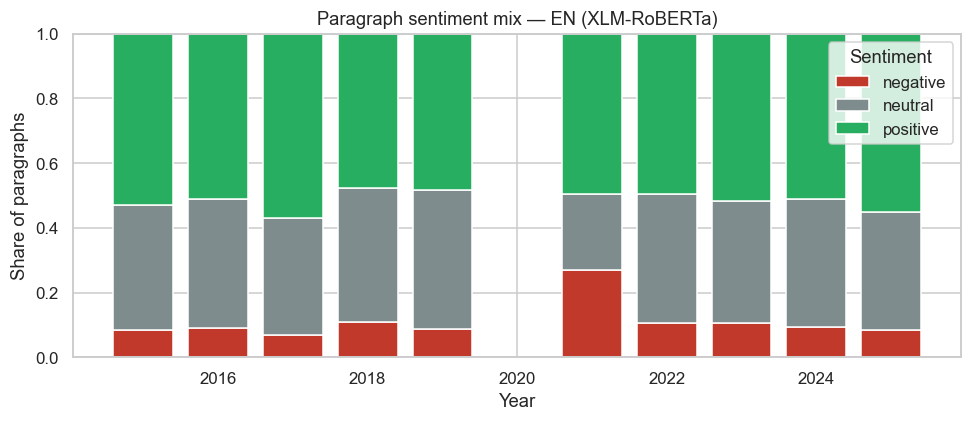

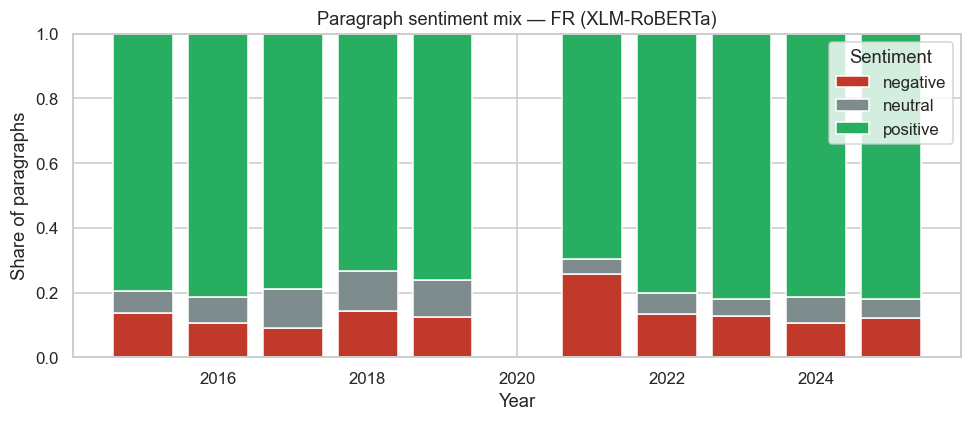

In [80]:

# Stacked bar: sentiment mix per year (one chart per language)
for lang in ("en", "fr"):
    sub = year_lang[year_lang["lang"] == lang]
    pivot = sub.pivot(index="year", columns="pred_label", values="share")
    for col in ("negative", "neutral", "positive"):
        if col not in pivot.columns:
            pivot[col] = 0.0
    pivot = pivot[["negative", "neutral", "positive"]]
    fig, ax = plt.subplots(figsize=(9, 4))
    bottom = np.zeros(len(pivot))
    years = pivot.index.to_numpy()
    for label in pivot.columns:
        vals = pivot[label].to_numpy()
        ax.bar(years, vals, bottom=bottom, label=label, color=SENTIMENT_COLORS[label])
        bottom += vals
    ax.set_ylim(0, 1)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of paragraphs")
    ax.set_title(f"Paragraph sentiment mix — {lang.upper()} (XLM-RoBERTa)")
    ax.legend(title="Sentiment", loc="upper right")
    plt.tight_layout()
    savefig(f"sentiment_mix_{lang}.png")
    plt.show()


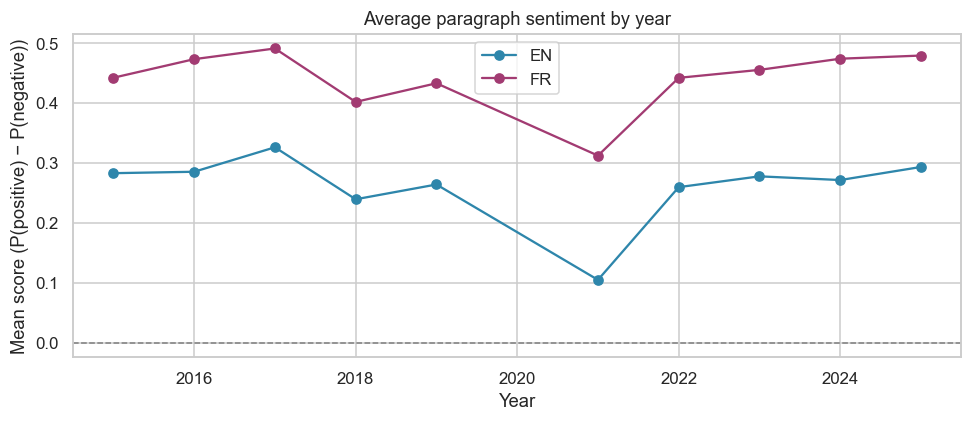

In [81]:

# Mean signed score (positive − negative) by year — EN vs FR on one chart
mean_signed = scored.groupby(["year", "lang"])["sentiment_signed"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
for lang in ("en", "fr"):
    sub = mean_signed[mean_signed["lang"] == lang]
    ax.plot(
        sub["year"],
        sub["sentiment_signed"],
        marker="o",
        label=lang.upper(),
        color=LANG_COLORS[lang],
    )
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("Year")
ax.set_ylabel("Mean score (P(positive) − P(negative))")
ax.set_title("Average paragraph sentiment by year")
ax.legend()
plt.tight_layout()
savefig("sentiment_signed_timeline.png")
plt.show()


## 3. Monolingual models (FinBERT EN, CamemBERT FR)


In [82]:

paragraphs_en = paragraphs[paragraphs["lang"] == "en"].copy()
paragraphs_fr = paragraphs[paragraphs["lang"] == "fr"].copy()
print(f"EN paragraphs: {len(paragraphs_en):,}  |  FR paragraphs: {len(paragraphs_fr):,}")

scored_finbert = load_or_score(
    paragraphs_en,
    CACHE_FINBERT,
    MODEL_FINBERT,
    RERUN_MONO_INFERENCE,
    desc="FinBERT (EN)",
)
scored_finbert["model"] = "finbert"

scored_camembert = load_or_score(
    paragraphs_fr,
    CACHE_CAMEMBERT,
    MODEL_CAMEMBERT,
    RERUN_MONO_INFERENCE,
    desc="CamemBERT (FR)",
)
scored_camembert["model"] = "camembert"


EN paragraphs: 11,852  |  FR paragraphs: 12,746
Loaded cache: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/outputs/sentiment_finbert_en_paragraphs.csv (11,853 rows)
Loaded cache: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/outputs/sentiment_camembert_fr_paragraphs.csv (12,750 rows)


## 4. Model comparison


In [83]:

def pair_key(df: pd.DataFrame) -> pd.Series:
    """Align EN/FR files that share chapter slug (not word-aligned TMX)."""
    stem = df["basename"].str.replace(r"-(en|fr|eng|fra)\.html$", "", regex=True, flags=re.I)
    return df["year"].astype(str) + "|" + df["doc_type"] + "|" + stem + "|" + df["paragraph_idx"].astype(str)


# One row per (paragraph, model) for comparable metrics
cols = [
    "year",
    "lang",
    "file",
    "basename",
    "doc_type",
    "paragraph_idx",
    "text",
    "words",
    "model",
    "pred_label",
    "score_negative",
    "score_neutral",
    "score_positive",
    "sentiment_signed",
]

all_scored = pd.concat(
    [
        scored_xlm[cols],
        scored_finbert[cols],
        scored_camembert[cols],
    ],
    ignore_index=True,
)

# Per-language model: XLM-R on both langs; FinBERT EN only; CamemBERT FR only
model_lang = {
    "xlm-roberta": {"en", "fr"},
    "finbert": {"en"},
    "camembert": {"fr"},
}
rows = []
for model, langs in model_lang.items():
    sub = all_scored[(all_scored["model"] == model) & (all_scored["lang"].isin(langs))]
    mix = (
        sub.groupby(["year", "lang", "pred_label"])
        .size()
        .reset_index(name="n")
    )
    mix["share"] = mix.groupby(["year", "lang"])["n"].transform(lambda s: s / s.sum())
    mix["model"] = model
    rows.append(mix)
compare_mix = pd.concat(rows, ignore_index=True)

pivot_compare = compare_mix.pivot_table(
    index=["year", "lang", "model"],
    columns="pred_label",
    values="share",
    fill_value=0,
).reset_index()
display(pivot_compare.round(3).head(12))


pred_label,year,lang,model,negative,neutral,positive
0,2015,en,finbert,0.206,0.255,0.538
1,2015,en,xlm-roberta,0.084,0.388,0.528
2,2015,fr,camembert,0.087,0.100,0.813
3,2015,fr,xlm-roberta,0.137,0.067,0.796
4,2016,en,finbert,0.098,0.394,0.508
5,2016,en,xlm-roberta,0.092,0.398,0.510
6,2016,fr,camembert,0.087,0.067,0.847
7,2016,fr,xlm-roberta,0.108,0.080,0.812
8,2017,en,finbert,0.069,0.449,0.483
9,2017,en,xlm-roberta,0.068,0.362,0.570


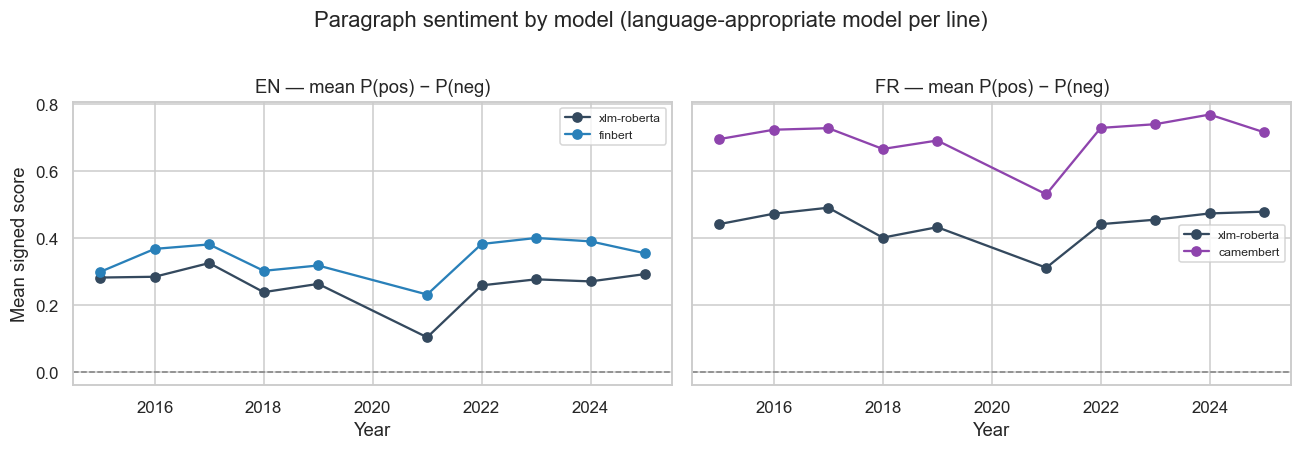

In [84]:

MODEL_PALETTE = {
    "xlm-roberta": "#34495e",
    "finbert": "#2980b9",
    "camembert": "#8e44ad",
}

# Mean signed score by year — three models, EN and FR panels
mean_by_model = (
    all_scored.groupby(["year", "lang", "model"])["sentiment_signed"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, lang in zip(axes, ("en", "fr")):
    sub = mean_by_model[mean_by_model["lang"] == lang]
    for model in ("xlm-roberta", "finbert", "camembert"):
        msub = sub[sub["model"] == model]
        if msub.empty:
            continue
        ax.plot(
            msub["year"],
            msub["sentiment_signed"],
            marker="o",
            label=model,
            color=MODEL_PALETTE.get(model, "gray"),
        )
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_xlabel("Year")
    ax.set_title(f"{lang.upper()} — mean P(pos) − P(neg)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Mean signed score")
fig.suptitle("Paragraph sentiment by model (language-appropriate model per line)", y=1.02)
plt.tight_layout()
savefig("sentiment_signed_timeline_by_model.png")
plt.show()


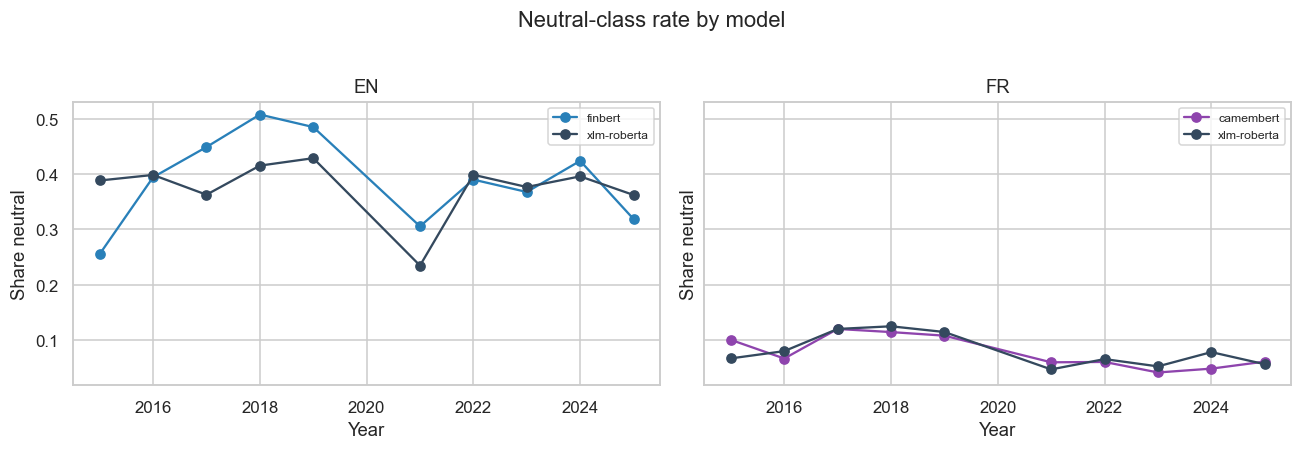

In [85]:

# Neutral share by year — models often disagree on how much budget prose is "neutral"
neutral_share = (
    all_scored.assign(is_neutral=lambda d: d["pred_label"] == "neutral")
    .groupby(["year", "lang", "model"])["is_neutral"]
    .mean()
    .reset_index(name="neutral_share")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, lang in zip(axes, ("en", "fr")):
    sub = neutral_share[neutral_share["lang"] == lang]
    for model in sub["model"].unique():
        msub = sub[sub["model"] == model]
        ax.plot(
            msub["year"],
            msub["neutral_share"],
            marker="o",
            label=model,
            color=MODEL_PALETTE.get(model, "gray"),
        )
    ax.set_xlabel("Year")
    ax.set_ylabel("Share neutral")
    ax.set_title(lang.upper())
    ax.legend(fontsize=8)
fig.suptitle("Neutral-class rate by model", y=1.02)
plt.tight_layout()
savefig("sentiment_neutral_share_by_model.png")
plt.show()


In [86]:

# Structural EN–FR pairs (same year, doc_type, slug stem, paragraph index)
# Not translation-aligned; useful as a coarse bilingual consistency check.

def prep_pairs(df: pd.DataFrame) -> pd.DataFrame:
    out = df[
        ["year", "lang", "doc_type", "basename", "paragraph_idx", "pred_label", "sentiment_signed"]
    ].copy()
    out["pair_id"] = pair_key(out)
    return out


xlm_pairs = prep_pairs(scored_xlm)
en_xlm = xlm_pairs[xlm_pairs["lang"] == "en"].rename(
    columns={"pred_label": "pred_en", "sentiment_signed": "signed_en"}
)
fr_xlm = xlm_pairs[xlm_pairs["lang"] == "fr"].rename(
    columns={"pred_label": "pred_fr", "sentiment_signed": "signed_fr"}
)
merged_xlm = en_xlm.merge(
    fr_xlm[["pair_id", "pred_fr", "signed_fr"]],
    on="pair_id",
    how="inner",
)

agree_xlm = (merged_xlm["pred_en"] == merged_xlm["pred_fr"]).mean()
print(f"XLM-RoBERTa label agreement on structural EN–FR pairs: {agree_xlm:.1%}  (n={len(merged_xlm):,})")

# FinBERT (EN) vs CamemBERT (FR) on the same structural keys
fin = prep_pairs(scored_finbert).rename(
    columns={"pred_label": "pred_en", "sentiment_signed": "signed_en"}
)
cam = prep_pairs(scored_camembert).rename(
    columns={"pred_label": "pred_fr", "sentiment_signed": "signed_fr"}
)
merged_mono = fin.merge(cam[["pair_id", "pred_fr", "signed_fr"]], on="pair_id", how="inner")
agree_mono = (merged_mono["pred_en"] == merged_mono["pred_fr"]).mean()
print(
    f"FinBERT (EN) vs CamemBERT (FR) agreement on structural pairs: {agree_mono:.1%}  "
    f"(n={len(merged_mono):,})"
)

# Cross-model on English only: XLM-R vs FinBERT (same paragraphs)
m_en = scored_xlm[scored_xlm["lang"] == "en"].merge(
    scored_finbert[["year", "file", "paragraph_idx", "pred_label", "sentiment_signed"]],
    on=["year", "file", "paragraph_idx"],
    suffixes=("_xlm", "_fin"),
    how="inner",
)
agree_en_models = (m_en["pred_label_xlm"] == m_en["pred_label_fin"]).mean()
print(f"English: XLM-RoBERTa vs FinBERT agreement: {agree_en_models:.1%}  (n={len(m_en):,})")

conf = pd.crosstab(merged_xlm["pred_en"], merged_xlm["pred_fr"], normalize="index").round(3)
print("\nXLM-RoBERTa EN → FR confusion (row=EN label):")
display(conf)


XLM-RoBERTa label agreement on structural EN–FR pairs: 51.6%  (n=11,834)
FinBERT (EN) vs CamemBERT (FR) agreement on structural pairs: 49.1%  (n=11,834)
English: XLM-RoBERTa vs FinBERT agreement: 66.4%  (n=11,852)

XLM-RoBERTa EN → FR confusion (row=EN label):


pred_fr,negative,neutral,positive
pred_en,,,
negative,0.309,0.072,0.619
neutral,0.129,0.122,0.749
positive,0.084,0.062,0.854


## 5. XLM-RoBERTa — section types and spot-checks


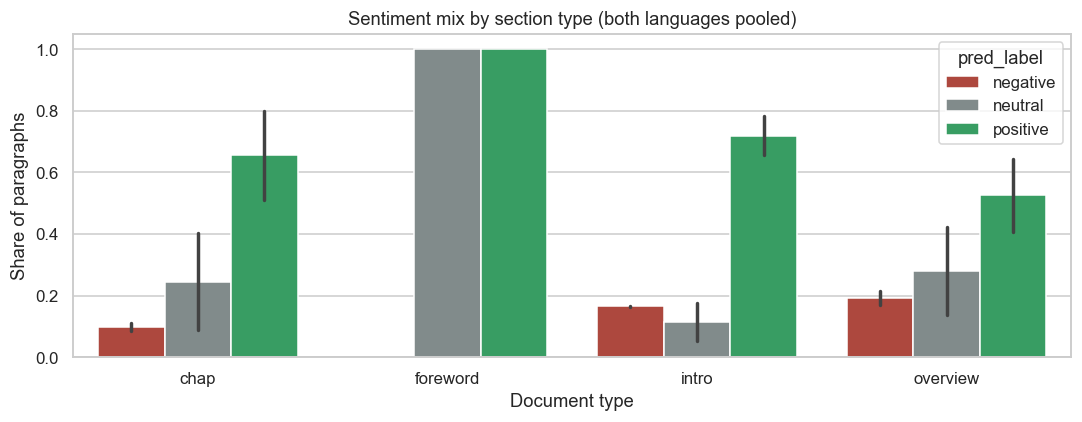

In [87]:

by_type = (
    scored.groupby(["doc_type", "lang", "pred_label"])
    .size()
    .reset_index(name="n")
)
by_type["share"] = by_type.groupby(["doc_type", "lang"])["n"].transform(lambda s: s / s.sum())
fig, ax = plt.subplots(figsize=(10, 4))
plot_types = [t for t in ["chap", "intro", "overview", "foreword"] if t in by_type["doc_type"].unique()]
sns.barplot(
    data=by_type[by_type["doc_type"].isin(plot_types)],
    x="doc_type",
    y="share",
    hue="pred_label",
    hue_order=["negative", "neutral", "positive"],
    palette=SENTIMENT_COLORS,
    ax=ax,
)
ax.set_xlabel("Document type")
ax.set_ylabel("Share of paragraphs")
ax.set_title("Sentiment mix by section type (both languages pooled)")
plt.tight_layout()
savefig("sentiment_by_doctype.png")
plt.show()


In [88]:

def show_examples(lang: str, label: str, n: int = 3) -> None:
    sub = scored[(scored["lang"] == lang) & (scored["pred_label"] == label)].copy()
    if sub.empty:
        print(f"No {label} examples for {lang}")
        return
    score_col = f"score_{label}"
    sub = sub.nlargest(n, score_col)
    print(f"\n=== {lang.upper()} — top {n} {label} paragraphs ===")
    for _, row in sub.iterrows():
        snippet = normalize_whitespace(row["text"].replace("\n", " "))
        print(f"[{row['year']} {row['basename']}] (p={row[score_col]:.3f}) {snippet[:280]}...\n")


for lang in ("en", "fr"):
    for label in ("positive", "negative"):
        show_examples(lang, label, n=2)



=== EN — top 2 positive paragraphs ===
[2023 intro-en.html] (p=0.920) We have the remarkable good fortune to live in the greatest country in the world....

[2023 chap3-en.html] (p=0.918) Together, these two shifts represent a significant economic opportunity for Canada....


=== EN — top 2 negative paragraphs ===
[2021 intro-en.html] (p=0.948) Our elders have been this virus's principal victims. The disease has preyed on them mercilessly, cutting short thousands of lives and forcing all seniors into fearful isolation, for more than a year....

[2022 intro-en.html] (p=0.947) It was a shattering economic blow. The Great Depression scarred this country for a generation or more. It was entirely reasonable to fear that the COVID recession would likewise hamstring us for years; that millions of Canadians would still today be without jobs; and that the tas...


=== FR — top 2 positive paragraphs ===
[2023 intro-fr.html] (p=0.954) Nous avons la chance incroyable de vivre dans le meilleur pays

### Interpretation notes

- **XLM-RoBERTa** was trained on social media; **FinBERT** on financial phrases; **CamemBERT** on French tweets. Absolute scores are not comparable across models — compare **trends** and **label mixes**.
- **FinBERT / CamemBERT** are applied only to their native language; do not compare raw EN FinBERT scores to FR CamemBERT scores as if they were on the same scale.
- Structural EN–FR **pair agreement** uses matching file slug + paragraph index, not TMX alignment (see EDA notebook for 2025 sentence pairs).
- Set `NARRATIVE_ONLY = False` to include annexes; set `RERUN_XLM_INFERENCE` / `RERUN_MONO_INFERENCE` to True after corpus or model changes.
- Cached sentiment scores are merged with **fresh paragraph text** on each run, so whitespace or extraction fixes apply without re-inferring.


In [89]:

import platform

print("Completed:", datetime.now(timezone.utc).isoformat())
print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("Device:", DEVICE)
print("Paragraphs (corpus):", len(paragraphs))
print("XLM-R cache:", CACHE_XLM, "—", len(scored_xlm))
print("FinBERT cache:", CACHE_FINBERT, "—", len(scored_finbert))
print("CamemBERT cache:", CACHE_CAMEMBERT, "—", len(scored_camembert))
print("Figures:", FIGURES_DIR)


Completed: 2026-05-29T21:58:16.573728+00:00
Python: 3.13.0
Torch: 2.12.0
Device: mps
Paragraphs (corpus): 24598
XLM-R cache: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/outputs/sentiment_xlm_roberta_paragraphs.csv — 24598
FinBERT cache: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/outputs/sentiment_finbert_en_paragraphs.csv — 11852
CamemBERT cache: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/outputs/sentiment_camembert_fr_paragraphs.csv — 12746
Figures: /Users/kenichisutan/Documents/Paris-Saclay/UQTR/canadian-budget-en-fr-sentiment-analysis/data/figures/sentiment
